#   [Py4Hw User Guide](../UserGuide.ipynb)> 5.1 The Simulator
###  [Next: 5.2 Scopes](Scopes.ipynb)


The simulator can be obtained from the HWSystem.

The current simulator is implemented as a cycle based simulator.
You basically call the method clk to advance the number of clocks you want.

In [1]:
import py4hw

sys = py4hw.HWSystem()
sim = sys.getSimulator()
sim.clk(1)

### The interpretation of simulation waveforms
Combinational circuits are continuosly working, they respond to some input after some delay.
On the other hand sequential circuits are only active on clock edges, they respond to some input when the clock edge arrive after some delay.

Functional Simulation usually use diagrams where the delay of the outputs is eliminated. So you should interpret that in a clock edge, the right part is what is stable before the clock edge, and the right part is what is stable after some delay after the clock edge. This is vital to be able to interpret correctly the simulation diagrams.

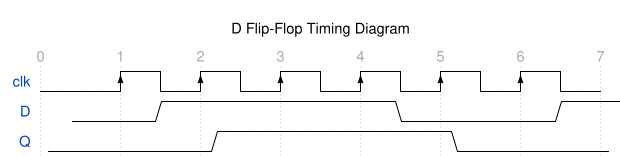

In [2]:
import Simulation as sim
sim.drawDelayDiagram()


### Simulation orchestration
When we call the simulator to advance a number of clocks, the framework first calls the propagate functions to support the case with some script directly changed the value of a wire calling the "put" method.

Then it starts to run a simulation cycle, calling first the monitor functions, then the clock advance functions and finally propagating the combinational chains.

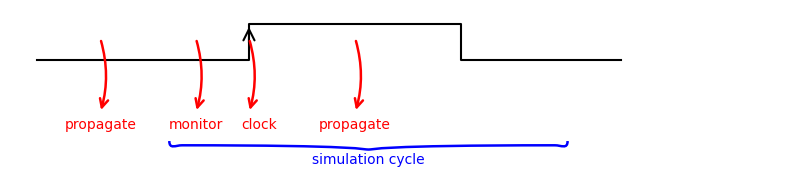

In [3]:
sim.drawSimulationRelatedFunctions()

In the following example we do the same thing in py4hw.
Several things to consider:
- Sequence object starts with 0 as initial state and outputs the first element of the list after the first clock edge

In [4]:
import py4hw

hw = py4hw.HWSystem()

D = hw.wire('D')
Q = hw.wire('Q')

py4hw.Sequence(hw, 'D', [1,1,1,0,0], D)
py4hw.Reg(hw, 'Q', d=D, q=Q)

wvf = py4hw.Waveform(hw, 'wvf', [D,Q])
hw.getSimulator().clk(7)

wvf.draw_wavedrom()

In the following interactive window the same output is shown, but in this case the propagation delay is eliminated and it is shown in the standard way used by many functional simulators.

In [7]:
wvf.gui()
hw.getSimulator().clk(7)

SystemWindow


### Internals

The simulator object has the following fields and methods

|Field| Description|
| :-- | :-- |
| total_clks | The number of clocks run from the initial time of the session |
| sys | The HWSystem associated with the simulator |
| listeners | A list of the objects that listen to simulator events |

|Method| Description|
| :-- | :-- |
| __init__ | Constructor |
|  propagateAll | Propagates all combinational circuits |
| topologicalSort | We segment the circuit by clock drivers. Sorts all the elements of the circuit so that cycle-base simulation is possible. Clockables do not require any order. Propagatables must be sorted in propagation order, so when we insert we should check if there are elements in the list that depend on the current item, and in this case we should place it before them |
| getOrCreateClockDriverSimulator | get a clock driver simulator |
| findFirstDependentPosition | We look at the outputs of the provided circuit and find all the dependent cells, then we locate them in |
| clk | Advance a number of clock cycles |
| _clk_cycle | Advance one clock cycle |
| stop | Stop the simulation |
| addListener | Add a listener of the simulator events |
| _notifyListeners | Notify the listeners of a simulator event |

### Summary 
- There is a singleton object that implements the Simulator which is attached to HWSystem
- The simulator is a cycle-based simulator